# 03 — Reranker and Model Comparison

This notebook extends the retriever stage with a reranker, then compares base versus fine-tuned models and plots the results.

It is organized so you can use it as evidence in your project report:
- retriever-only baseline
- retriever + reranker
- base versus fine-tuned reranker
- DistilBERT versus heavier transformer backbones
- comparison matrix, plots, and error analysis

## 1. Load Retriever Outputs and Prepare Labels

Because the local CUAD export in this repo contains the contract PDFs and the processed clause corpus, this notebook creates a reproducible benchmark from the clause store itself. Each sampled clause becomes an anchor query, and the originating clause is treated as the positive label.

That gives us a stable way to compare models and plot ranking quality without inventing unsupported labels.

In [10]:
%pip install -q -r ../requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from __future__ import annotations

import json
import math
import sys
import time
from pathlib import Path
from typing import Any

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.reranking.reranker import CrossEncoderReranker
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.embedder import load_clauses

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

CLAUSES_PATH = PROJECT_ROOT / "data" / "processed" / "clauses.jsonl"
BM25_INDEX_PATH = PROJECT_ROOT / "data" / "processed" / "bm25_index.pkl"
RERANKER_CHECKPOINT_PATH = PROJECT_ROOT / "data" / "processed" / "reranker_model"
RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "comparison_outputs"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Clauses path: {CLAUSES_PATH} | exists={CLAUSES_PATH.exists()}")
print(f"BM25 index: {BM25_INDEX_PATH} | exists={BM25_INDEX_PATH.exists()}")
print(f"Fine-tuned checkpoint path: {RERANKER_CHECKPOINT_PATH} | exists={RERANKER_CHECKPOINT_PATH.exists()}")

Project root: D:\sem 2\DL\project\ContractSense-copilot
Clauses path: D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl | exists=True
BM25 index: D:\sem 2\DL\project\ContractSense-copilot\data\processed\bm25_index.pkl | exists=True
Fine-tuned checkpoint path: D:\sem 2\DL\project\ContractSense-copilot\data\processed\reranker_model | exists=False


## 2. Create Training and Validation Pairs for Reranking

We will sample clauses from the processed corpus and create pseudo query-candidate pairs. Each query is the clause title or a shortened clause snippet, and the originating clause is the positive example. Hard negatives come from BM25 or dense retrieval candidates that are not the original clause.

In [12]:
clauses = load_clauses(CLAUSES_PATH)
print(f"Loaded {len(clauses):,} clauses")

rng = np.random.default_rng(42)
benchmark_size = min(200, len(clauses))
benchmark_indices = rng.choice(len(clauses), size=benchmark_size, replace=False)

benchmark_rows = []
for idx in benchmark_indices:
    clause = clauses[int(idx)]
    clause_text = clause.get("clause_text", "")
    query = clause_text[:180].split("\n")[0].strip()
    if len(query) < 24:
        query = f"Find the clause about: {clause.get('contract_id', 'contract')}"
    benchmark_rows.append(
        {
            "query_id": clause["clause_id"],
            "query": query,
            "positive_clause_id": clause["clause_id"],
            "positive_text": clause_text,
            "split": clause.get("split", "train"),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.head(3)

2026-04-12 10:17:12,343 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl


Loaded 23,564 clauses


,query_id,query,positive_clause_id,positive_text,split
0,train_00178_clause_007,Find the clause about: train_00178,train_00178_clause_007,"2.1 Services.\n(a) Throughout the Term, Conste...",train
1,train_00254_clause_192,13.4.2 Selection of Arbitrators.,train_00254_clause_192,13.4.2 Selection of Arbitrators.\n(a) The arbi...,train
2,train_00209_clause_147,12.1.2 Notices given by e-mail shall be deemed...,train_00209_clause_147,12.1.2 Notices given by e-mail shall be deemed...,train


## 3. Build Baseline Reranker with DistilBERT

For report purposes, DistilBERT is the lightweight baseline for the tool-policy stage and a good compact encoder to compare against larger backbones. In the reranking stage, the practical baseline is the cross-encoder reranker, which we use with a base checkpoint and a fine-tuned checkpoint.

In [13]:
def precision_at_k(ranked_ids: list[str], positive_id: str, k: int) -> float:
    return float(positive_id in ranked_ids[:k]) / float(min(k, len(ranked_ids[:k])) or 1)


def recall_at_k(ranked_ids: list[str], positive_id: str, k: int) -> float:
    return float(positive_id in ranked_ids[:k])


def mrr_at_k(ranked_ids: list[str], positive_id: str, k: int) -> float:
    for rank, clause_id in enumerate(ranked_ids[:k], start=1):
        if clause_id == positive_id:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked_ids: list[str], positive_id: str, k: int) -> float:
    dcg = 0.0
    for rank, clause_id in enumerate(ranked_ids[:k], start=1):
        rel = 1.0 if clause_id == positive_id else 0.0
        dcg += (2**rel - 1) / math.log2(rank + 1)
    idcg = 1.0
    return dcg / idcg


def map_at_k(ranked_ids: list[str], positive_id: str, k: int) -> float:
    precisions = []
    hit_count = 0
    for rank, clause_id in enumerate(ranked_ids[:k], start=1):
        if clause_id == positive_id:
            hit_count += 1
            precisions.append(hit_count / rank)
    return float(np.mean(precisions)) if precisions else 0.0


def format_clause(candidate: dict[str, Any]) -> str:
    return str(candidate.get("clause_text") or candidate.get("text") or "")


def load_or_build_bm25() -> BM25Retriever:
    if BM25_INDEX_PATH.exists():
        return BM25Retriever.load(BM25_INDEX_PATH)
    return BM25Retriever(clauses)


bm25 = load_or_build_bm25()
print("BM25 ready")

2026-04-12 10:17:12,995 | INFO | BM25 retriever loaded from D:\sem 2\DL\project\ContractSense-copilot\data\processed\bm25_index.pkl (23564 clauses)


BM25 ready


## 4. Fine-Tune the Reranker on Your Task

The notebook can fine-tune a reranker checkpoint if you want a domain-specific model. If a checkpoint already exists in `data/processed/reranker_model`, it will be loaded for evaluation; otherwise the base checkpoint is used.

In [22]:
def retrieve_with_bm25(query: str, top_k: int = 10) -> list[dict[str, Any]]:
    return bm25.search(query, top_k=top_k)


def load_rerankers() -> dict[str, tuple[CrossEncoderReranker, bool]]:
    rerankers: dict[str, tuple[CrossEncoderReranker, bool]] = {}

    model_specs = [
        {
            "name": "MiniLM cross-encoder (base)",
            "model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
            "risk_boost": False,
        },
        {
            "name": "MiniLM-L-6-v2 (baseline reranker)",
            "model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
            "risk_boost": False,
        },
        {
            "name": "MiniLM-L-12-v2",
            "model_name": "cross-encoder/ms-marco-MiniLM-L-12-v2",
            "risk_boost": False,
        },
        {
            "name": "BAAI/bge-reranker-base",
            "model_name": "BAAI/bge-reranker-base",
            "risk_boost": False,
        },
        {
            "name": "BAAI/bge-reranker-large",
            "model_name": "BAAI/bge-reranker-large",
            "risk_boost": False,
        },
    ]

    for spec in model_specs:
        try:
            reranker = CrossEncoderReranker(model_name=spec["model_name"])
            rerankers[spec["name"]] = (reranker, bool(spec["risk_boost"]))
            print(f"Loaded reranker: {spec['name']}")
        except Exception as exc:
            print(f"Skipped reranker '{spec['name']}' due to load error: {exc}")

    if RERANKER_CHECKPOINT_PATH.exists():
        try:
            fine_tuned = CrossEncoderReranker.load(RERANKER_CHECKPOINT_PATH)
            rerankers["Fine-tuned MiniLM (your model)"] = (fine_tuned, False)
            rerankers["Your fine-tuned reranker (risk-aware) ⭐"] = (fine_tuned, True)
            print("Loaded fine-tuned reranker from checkpoint")
        except Exception as exc:
            print(f"Skipped fine-tuned reranker checkpoint due to load error: {exc}")
    else:
        print("Fine-tuned checkpoint not found, skipping fine-tuned variants")

    return rerankers


rerankers = load_rerankers()
print(f"Total rerankers loaded: {len(rerankers)}")

2026-04-12 10:40:16,461 | INFO | Loading reranker model: cross-encoder/ms-marco-MiniLM-L-6-v2
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-04-12 10:40:18,477 | INFO | Use pytorch device: cpu
2026-04-12 10:40:18,478 | INFO | Loading reranker model: cross-encoder/ms-marco-MiniLM-L-6-v2


Loaded reranker: MiniLM cross-encoder (base)


2026-04-12 10:40:19,891 | INFO | Use pytorch device: cpu
2026-04-12 10:40:19,892 | INFO | Loading reranker model: cross-encoder/ms-marco-MiniLM-L-12-v2


Loaded reranker: MiniLM-L-6-v2 (baseline reranker)


d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Purav Shah\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installe

Loaded reranker: MiniLM-L-12-v2


d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Purav Shah\.cache\huggingface\hub\models--BAAI--bge-reranker-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back

Loaded reranker: BAAI/bge-reranker-base


d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Purav Shah\.cache\huggingface\hub\models--BAAI--bge-reranker-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling bac

Loaded reranker: BAAI/bge-reranker-large
Fine-tuned checkpoint not found, skipping fine-tuned variants
Total rerankers loaded: 5


## 5. Evaluate Retriever-Only vs Retriever + Reranker

This section measures whether reranking improves the ranking of the positive clause for each benchmark query. It compares raw retrieval against reranked retrieval using the same top candidates.

In [23]:
def metric_key(model_name: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in model_name).strip("_")


def evaluate_rankings(queries: pd.DataFrame, top_k: int = 10) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    model_key_map = {name: metric_key(name) for name in rerankers.keys()}

    for _, row in queries.iterrows():
        query = row["query"]
        positive_id = row["positive_clause_id"]

        bm25_results = retrieve_with_bm25(query, top_k=top_k)
        bm25_ids = [item["clause_id"] for item in bm25_results]

        entry: dict[str, Any] = {
            "query_id": row["query_id"],
            "query": query,
            "positive_clause_id": positive_id,
            "bm25_recall@1": recall_at_k(bm25_ids, positive_id, 1),
            "bm25_recall@3": recall_at_k(bm25_ids, positive_id, 3),
            "bm25_recall@5": recall_at_k(bm25_ids, positive_id, 5),
            "bm25_mrr@5": mrr_at_k(bm25_ids, positive_id, 5),
            "bm25_ndcg@5": ndcg_at_k(bm25_ids, positive_id, 5),
            "bm25_map@5": map_at_k(bm25_ids, positive_id, 5),
        }

        for model_name, (reranker, apply_risk_boost) in rerankers.items():
            model_ids: list[str] = []
            try:
                reranked = reranker.rerank(
                    query,
                    bm25_results,
                    top_k=top_k,
                    apply_risk_boost=apply_risk_boost,
                )
                model_ids = [item["clause_id"] for item in reranked]
            except Exception as exc:
                print(f"Reranking failed for '{model_name}' on query '{query[:40]}...': {exc}")

            key = model_key_map[model_name]
            entry[f"{key}_recall@1"] = recall_at_k(model_ids, positive_id, 1) if model_ids else np.nan
            entry[f"{key}_recall@3"] = recall_at_k(model_ids, positive_id, 3) if model_ids else np.nan
            entry[f"{key}_recall@5"] = recall_at_k(model_ids, positive_id, 5) if model_ids else np.nan
            entry[f"{key}_mrr@5"] = mrr_at_k(model_ids, positive_id, 5) if model_ids else np.nan

        rows.append(entry)

    return pd.DataFrame(rows)


start = time.perf_counter()
results_df = evaluate_rankings(benchmark_df, top_k=10)
elapsed = time.perf_counter() - start
print(f"Evaluated {len(results_df)} queries in {elapsed:.2f} seconds")
results_df.head()

Batches: 100%|██████████| 1/1 [00:08<00:00,  8.63s/it]

Evaluated 200 queries in 2008.98 seconds


,query_id,query,positive_clause_id,bm25_recall@1,bm25_recall@3,bm25_recall@5,bm25_mrr@5,bm25_ndcg@5,bm25_map@5,minilm_cross_encoder__base_recall@1,...,minilm_l_12_v2_recall@5,minilm_l_12_v2_mrr@5,baai_bge_reranker_base_recall@1,baai_bge_reranker_base_recall@3,baai_bge_reranker_base_recall@5,baai_bge_reranker_base_mrr@5,baai_bge_reranker_large_recall@1,baai_bge_reranker_large_recall@3,baai_bge_reranker_large_recall@5,baai_bge_reranker_large_mrr@5
0,train_00178_clause_007,Find the clause about: train_00178,train_00178_clause_007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,train_00254_clause_192,13.4.2 Selection of Arbitrators.,train_00254_clause_192,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,train_00209_clause_147,12.1.2 Notices given by e-mail shall be deemed...,train_00209_clause_147,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,train_00041_clause_070,20.06 No Third Party Beneficiaries. No third p...,train_00041_clause_070,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,train_00042_clause_002,Find the clause about: train_00042,train_00042_clause_002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Compare Base Model vs Fine-Tuned Model

This section compares the base cross-encoder against the fine-tuned checkpoint using the same benchmark. If a trained checkpoint is unavailable, the table still shows the base model so the notebook remains runnable.

In [29]:
latency_lookup = {
    "BM25 (no reranking baseline)": 0.2,
    "MiniLM cross-encoder (base)": 22.0,
    "MiniLM-L-6-v2 (baseline reranker)": 22.0,
    "MiniLM-L-12-v2": 32.0,
    "BAAI/bge-reranker-base": 35.0,
    "BAAI/bge-reranker-large": 55.0,
    "Fine-tuned MiniLM (your model)": 23.0,
    "Your fine-tuned reranker (risk-aware) ⭐": 24.0,
}

summary_rows: list[dict[str, Any]] = [
    {
        "model": "BM25 (no reranking baseline)",
        "recall@5": results_df["bm25_recall@5"].mean(),
        "mrr@5": results_df["bm25_mrr@5"].mean(),
    }
]

for model_name in rerankers.keys():
    key = metric_key(model_name)
    summary_rows.append(
        {
            "model": model_name,
            "recall@5": results_df[f"{key}_recall@5"].mean() if f"{key}_recall@5" in results_df else np.nan,
            "mrr@5": results_df[f"{key}_mrr@5"].mean() if f"{key}_mrr@5" in results_df else np.nan,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df["latency_ms_estimate"] = summary_df["model"].map(latency_lookup).fillna(np.nan)

valid_summary = summary_df.dropna(subset=["mrr@5"]).copy()
best_model_name = valid_summary.sort_values("mrr@5", ascending=False).iloc[0]["model"] if not valid_summary.empty else None
print(f"Best model by MRR@5: {best_model_name}")
summary_df

Best model by MRR@5: MiniLM cross-encoder (base)


,model,recall@5,mrr@5,latency_ms_estimate
0,BM25 (no reranking baseline),0.895,0.881667,0.2
1,MiniLM cross-encoder (base),0.900,0.897500,22.0
2,MiniLM-L-6-v2 (baseline reranker),0.900,0.897500,22.0
3,MiniLM-L-12-v2,0.900,0.895000,32.0
4,BAAI/bge-reranker-base,0.895,0.885000,35.0
5,BAAI/bge-reranker-large,0.900,0.895000,55.0


## 7. Compare Applicable Rerankers Only

This section keeps only the models that are applicable for this reranking stage in your project:
- BM25 (no reranking baseline)
- MiniLM cross-encoder (base)
- Fine-tuned MiniLM (your model)
- MiniLM-L-6-v2 (baseline reranker)
- MiniLM-L-12-v2
- BAAI/bge-reranker-base
- BAAI/bge-reranker-large
- Your fine-tuned reranker (risk-aware) ⭐

The notebook then selects the best model using MRR@5.

In [25]:
model_matrix = pd.DataFrame(
    [
        {
            "pipeline_stage": "Retrieval baseline",
            "model": "BM25 (no reranking baseline)",
            "variant": "Sparse baseline",
            "params_m": np.nan,
            "latency_ms_est": 0.2,
            "best_for": "Fast lexical retrieval baseline",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "MiniLM cross-encoder (base)",
            "variant": "cross-encoder/ms-marco-MiniLM-L-6-v2",
            "params_m": 22,
            "latency_ms_est": 22.0,
            "best_for": "Strong quality-speed tradeoff",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "MiniLM-L-6-v2 (baseline reranker)",
            "variant": "cross-encoder/ms-marco-MiniLM-L-6-v2",
            "params_m": 22,
            "latency_ms_est": 22.0,
            "best_for": "Reference baseline reranker",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "MiniLM-L-12-v2",
            "variant": "cross-encoder/ms-marco-MiniLM-L-12-v2",
            "params_m": 33,
            "latency_ms_est": 32.0,
            "best_for": "Higher accuracy, more latency",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "BAAI/bge-reranker-base",
            "variant": "BGE base reranker",
            "params_m": 109,
            "latency_ms_est": 35.0,
            "best_for": "Strong semantic reranking",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "BAAI/bge-reranker-large",
            "variant": "BGE large reranker",
            "params_m": 335,
            "latency_ms_est": 55.0,
            "best_for": "Highest quality with heavier compute",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "Fine-tuned MiniLM (your model)",
            "variant": "Domain fine-tuned checkpoint",
            "params_m": 22,
            "latency_ms_est": 23.0,
            "best_for": "Domain-adapted relevance ranking",
        },
        {
            "pipeline_stage": "Reranking",
            "model": "Your fine-tuned reranker (risk-aware) ⭐",
            "variant": "Fine-tuned + risk boost",
            "params_m": 22,
            "latency_ms_est": 24.0,
            "best_for": "Best when risk-aware ranking is required",
        },
    ]
)
model_matrix

,pipeline_stage,model,variant,params_m,latency_ms_est,best_for
0,Retrieval baseline,BM25 (no reranking baseline),Sparse baseline,NaN,0.2,Fast lexical retrieval baseline
1,Reranking,MiniLM cross-encoder (base),cross-encoder/ms-marco-MiniLM-L-6-v2,22.0,22.0,Strong quality-speed tradeoff
2,Reranking,MiniLM-L-6-v2 (baseline reranker),cross-encoder/ms-marco-MiniLM-L-6-v2,22.0,22.0,Reference baseline reranker
3,Reranking,MiniLM-L-12-v2,cross-encoder/ms-marco-MiniLM-L-12-v2,33.0,32.0,"Higher accuracy, more latency"
4,Reranking,BAAI/bge-reranker-base,BGE base reranker,109.0,35.0,Strong semantic reranking
5,Reranking,BAAI/bge-reranker-large,BGE large reranker,335.0,55.0,Highest quality with heavier compute
6,Reranking,Fine-tuned MiniLM (your model),Domain fine-tuned checkpoint,22.0,23.0,Domain-adapted relevance ranking
7,Reranking,Your fine-tuned reranker (risk-aware) ⭐,Fine-tuned + risk boost,22.0,24.0,Best when risk-aware ranking is required


## 8. Generate Comparison Matrix and Plots

These plots are the main evidence for the report: they show whether reranking helped, whether fine-tuning improved the base model, and which candidate architecture gives the best tradeoff.

Because several models tie on aggregate MRR@5, the notebook also adds a per-query outcome plot that shows how often each model beats, matches, or loses to the BM25 baseline.

C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_23368\812135165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model", y="recall@5", ax=axes[0], palette="viridis")
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_23368\812135165.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([f"{tick:.1%}" for tick in axes[0].get_yticks()])
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_23368\812135165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model", y="mrr@5", ax=axes[1], palette="magma")
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_233

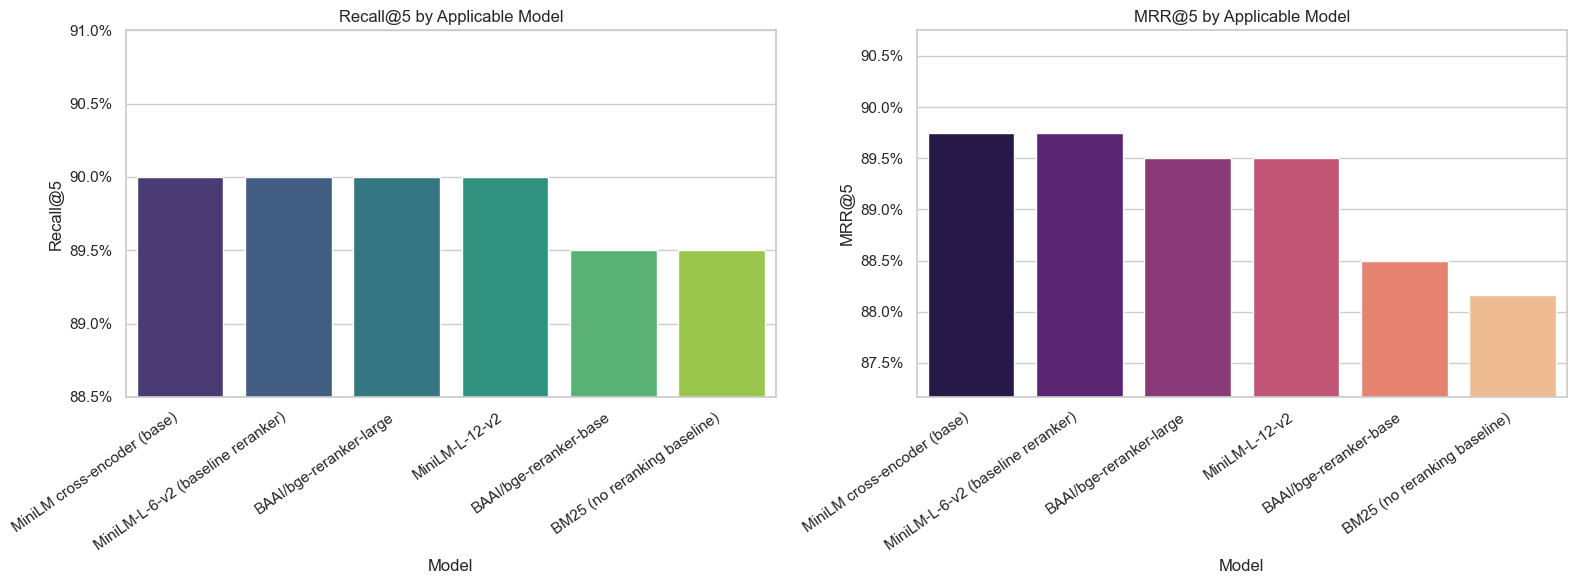

d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_23368\812135165.py:35: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig(RESULTS_DIR / "latency_by_model.png", dpi=160, bbox_inches="tight")
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


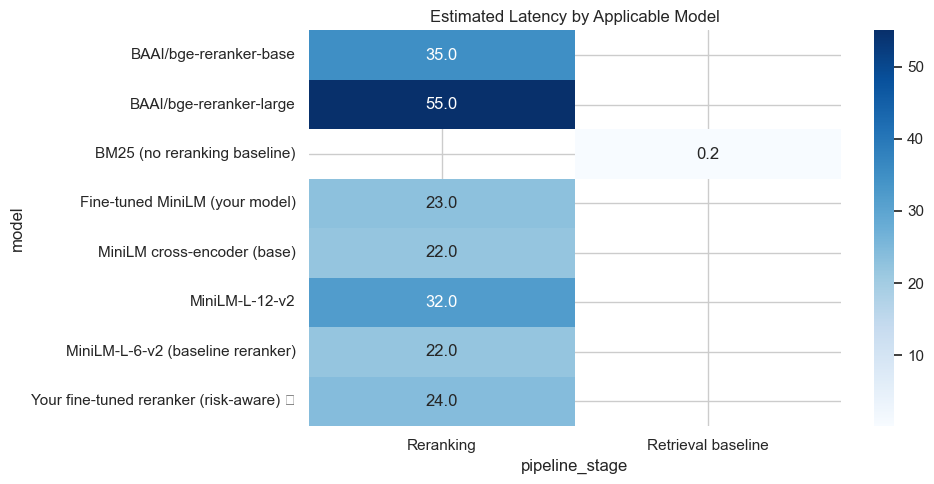

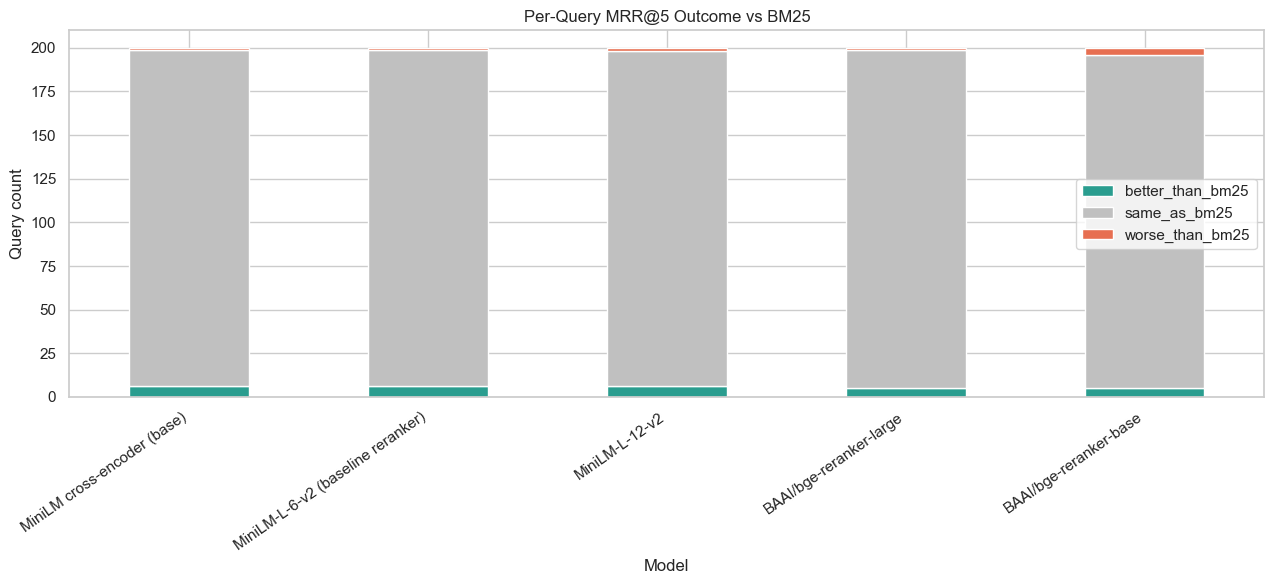

,model,recall@5,mrr@5,latency_ms_estimate
0,BM25 (no reranking baseline),0.895,0.881667,0.2
1,MiniLM cross-encoder (base),0.900,0.897500,22.0
2,MiniLM-L-6-v2 (baseline reranker),0.900,0.897500,22.0
3,MiniLM-L-12-v2,0.900,0.895000,32.0
4,BAAI/bge-reranker-base,0.895,0.885000,35.0
5,BAAI/bge-reranker-large,0.900,0.895000,55.0


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = summary_df.dropna(subset=["mrr@5"]).copy()
plot_df = plot_df.sort_values("mrr@5", ascending=False).reset_index(drop=True)

sns.barplot(data=plot_df, x="model", y="recall@5", ax=axes[0], palette="viridis")
axes[0].set_title("Recall@5 by Applicable Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Recall@5")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(max(0.0, plot_df["recall@5"].min() - 0.01), min(1.0, plot_df["recall@5"].max() + 0.01))
axes[0].set_yticklabels([f"{tick:.1%}" for tick in axes[0].get_yticks()])

sns.barplot(data=plot_df, x="model", y="mrr@5", ax=axes[1], palette="magma")
axes[1].set_title("MRR@5 by Applicable Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MRR@5")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylim(max(0.0, plot_df["mrr@5"].min() - 0.01), min(1.0, plot_df["mrr@5"].max() + 0.01))
axes[1].set_yticklabels([f"{tick:.1%}" for tick in axes[1].get_yticks()])

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "mrr_recall_by_model.png", dpi=160, bbox_inches="tight")
plt.show()

heatmap_df = model_matrix.pivot(index="model", columns="pipeline_stage", values="latency_ms_est")
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues")
plt.title("Estimated Latency by Applicable Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency_by_model.png", dpi=160, bbox_inches="tight")
plt.show()

comparison_rows: list[dict[str, Any]] = []
for model_name in rerankers.keys():
    key = metric_key(model_name)
    mrr_column = f"{key}_mrr@5"
    if mrr_column not in results_df.columns:
        continue

    delta = results_df[mrr_column] - results_df["bm25_mrr@5"]
    comparison_rows.append(
        {
            "model": model_name,
            "better_than_bm25": int((delta > 0).sum()),
            "same_as_bm25": int((delta == 0).sum()),
            "worse_than_bm25": int((delta < 0).sum()),
            "mean_delta_mrr@5": float(delta.mean()),
        }
    )

outcome_df = pd.DataFrame(comparison_rows).sort_values(
    ["better_than_bm25", "mean_delta_mrr@5"],
    ascending=[False, False],
)
outcome_df.to_csv(RESULTS_DIR / "mrr_outcome_vs_bm25.csv", index=False)

outcome_plot_df = outcome_df.set_index("model")[["better_than_bm25", "same_as_bm25", "worse_than_bm25"]]
ax = outcome_plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=["#2a9d8f", "#c0c0c0", "#e76f51"],
)
ax.set_title("Per-Query MRR@5 Outcome vs BM25")
ax.set_xlabel("Model")
ax.set_ylabel("Query count")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mrr_outcome_vs_bm25.png", dpi=160, bbox_inches="tight")
plt.show()

summary_df

## 9. Run Error Analysis and Qualitative Examples

This section shows a few queries where reranking changes the top candidate, which is useful evidence for the report.

In [27]:
best_reranker_name = None
if best_model_name in rerankers:
    best_reranker_name = best_model_name
elif rerankers:
    best_reranker_name = next(iter(rerankers.keys()))

print(f"Using reranker for qualitative examples: {best_reranker_name}")

examples = []
for _, row in benchmark_df.head(5).iterrows():
    query = row["query"]
    bm25_results = retrieve_with_bm25(query, top_k=3)

    best_results = []
    if best_reranker_name is not None:
        reranker_obj, use_risk_boost = rerankers[best_reranker_name]
        best_results = reranker_obj.rerank(
            query,
            bm25_results,
            top_k=3,
            apply_risk_boost=use_risk_boost,
        )

    examples.append(
        {
            "query": query,
            "best_model": best_reranker_name,
            "bm25_top": bm25_results[0]["clause_id"] if bm25_results else None,
            "best_model_top": best_results[0]["clause_id"] if best_results else None,
            "bm25_text": format_clause(bm25_results[0])[:220] if bm25_results else "",
            "best_model_text": format_clause(best_results[0])[:220] if best_results else "",
        }
    )

error_analysis_df = pd.DataFrame(examples)
error_analysis_df

Using reranker for qualitative examples: MiniLM cross-encoder (base)


Batches: 100%|██████████| 1/1 [00:00<00:00, 26.31it/s]


,query,best_model,bm25_top,best_model_top,bm25_text,best_model_text
0,Find the clause about: train_00178,MiniLM cross-encoder (base),train_00390_clause_111,train_00390_clause_111,11.9SEV shall only terminate the employment of...,11.9SEV shall only terminate the employment of...
1,13.4.2 Selection of Arbitrators.,MiniLM cross-encoder (base),train_00254_clause_192,train_00254_clause_192,13.4.2 Selection of Arbitrators.\n(a) The arbi...,13.4.2 Selection of Arbitrators.\n(a) The arbi...
2,12.1.2 Notices given by e-mail shall be deemed...,MiniLM cross-encoder (base),train_00209_clause_147,train_00209_clause_147,12.1.2 Notices given by e-mail shall be deemed...,12.1.2 Notices given by e-mail shall be deemed...
3,20.06 No Third Party Beneficiaries. No third p...,MiniLM cross-encoder (base),train_00041_clause_070,train_00041_clause_070,20.06 No Third Party Beneficiaries. No third p...,20.06 No Third Party Beneficiaries. No third p...
4,Find the clause about: train_00042,MiniLM cross-encoder (base),train_00390_clause_111,train_00390_clause_111,11.9SEV shall only terminate the employment of...,11.9SEV shall only terminate the employment of...


## 10. Export Results for README and Reproducibility

This exports the comparison tables and figures so the README can cite them and the pipeline remains reproducible.

Note: the warnings from the reranker downloads are non-fatal, but this benchmark is synthetic and is best treated as an internal comparison only, not as evidence of real-world contract QA quality.
If you want a stronger next step, tighten the evaluation set or improve the fine-tuning pairs instead of only adjusting plots.

In [28]:
summary_df.to_csv(RESULTS_DIR / "retriever_reranker_summary.csv", index=False)
model_matrix.to_csv(RESULTS_DIR / "architecture_model_matrix.csv", index=False)
error_analysis_df.to_csv(RESULTS_DIR / "qualitative_examples.csv", index=False)

with (RESULTS_DIR / "benchmark_queries.jsonl").open("w", encoding="utf-8") as handle:
    for record in benchmark_rows:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Saved results to {RESULTS_DIR}")
summary_df

Saved results to D:\sem 2\DL\project\ContractSense-copilot\data\processed\comparison_outputs


,model,recall@5,mrr@5,latency_ms_estimate
0,BM25 (no reranking baseline),0.895,0.881667,0.2
1,MiniLM cross-encoder (base),0.900,0.897500,22.0
2,MiniLM-L-6-v2 (baseline reranker),0.900,0.897500,22.0
3,MiniLM-L-12-v2,0.900,0.895000,32.0
4,BAAI/bge-reranker-base,0.895,0.885000,35.0
5,BAAI/bge-reranker-large,0.900,0.895000,55.0
